## 10. Histórico informado × medidas objetivas

### Objetivo

Esta seção tem como objetivo comparar informações sobre o histórico de saúde relatado pelos participantes com medidas objetivas obtidas durante os exames do NHANES.

São analisadas três situações:

- diabetes informado × HbA1c;
- hipertensão informada × pressão arterial medida;
- colesterol alto informado × colesterol total medido.

O objetivo dessas comparações é investigar como informações de naturezas diferentes se relacionam na amostra. O histórico informado representa uma condição relatada pelo participante, enquanto HbA1c, pressão arterial e colesterol total correspondem a medidas obtidas no período do exame.

As categorias construídas a partir das medidas clínicas são utilizadas exclusivamente para fins analíticos nesta EDA e não representam diagnósticos realizados pelo HealthSync.

Diferenças entre histórico informado e medida objetiva também não serão interpretadas automaticamente como erro, ausência de diagnóstico ou diagnóstico incorreto. Uma medida obtida em determinado momento não representa necessariamente todo o histórico clínico do participante.

Os pontos de corte utilizados nesta seção deverão ser acompanhados das respectivas referências clínicas na documentação final do projeto.

Importação de bibliotecas

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

Abrindo o csv, e testando se carregou corretamente

In [26]:
CAMINHO_CORE = "../../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)

display(df.head())

,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 10.1 Diabetes informado × HbA1c

**Pergunta da análise:** como as faixas analíticas de HbA1c estão distribuídas entre participantes com diferentes históricos informados de diabetes?

Para realizar essa comparação, a HbA1c é organizada nas mesmas faixas analíticas utilizadas anteriormente no perfil glicêmico:

- **< 5,7%**
- **5,7% a 6,4%**
- **≥ 6,5%**

Os percentuais são calculados dentro de cada categoria de diabetes informado. Dessa forma, cada linha da tabela percentual representa aproximadamente 100% dos participantes daquela categoria.

A categorização é utilizada para facilitar a comparação descritiva e não substitui uma avaliação clínica individual.

In [27]:
df["faixa_hba1c"] = pd.cut(
    df["hba1c"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    right=False,
    labels=[
        "< 5,7%",
        "5,7–6,4%",
        "≥ 6,5%"
    ]
)

tabela_diabetes_hba1c = pd.crosstab(
    df["diabetes_informado"],
    df["faixa_hba1c"]
)

display(tabela_diabetes_hba1c)

faixa_hba1c,"< 5,7%","5,7–6,4%","≥ 6,5%"
diabetes_informado,,,
Borderline,52,104,30
Nao,3089,1161,110
Sim,55,163,519


In [28]:
tabela_diabetes_hba1c_pct = (
    pd.crosstab(
        df["diabetes_informado"],
        df["faixa_hba1c"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

display(tabela_diabetes_hba1c_pct)

faixa_hba1c,"< 5,7%","5,7–6,4%","≥ 6,5%"
diabetes_informado,,,
Borderline,28.0,55.9,16.1
Nao,70.8,26.6,2.5
Sim,7.5,22.1,70.4


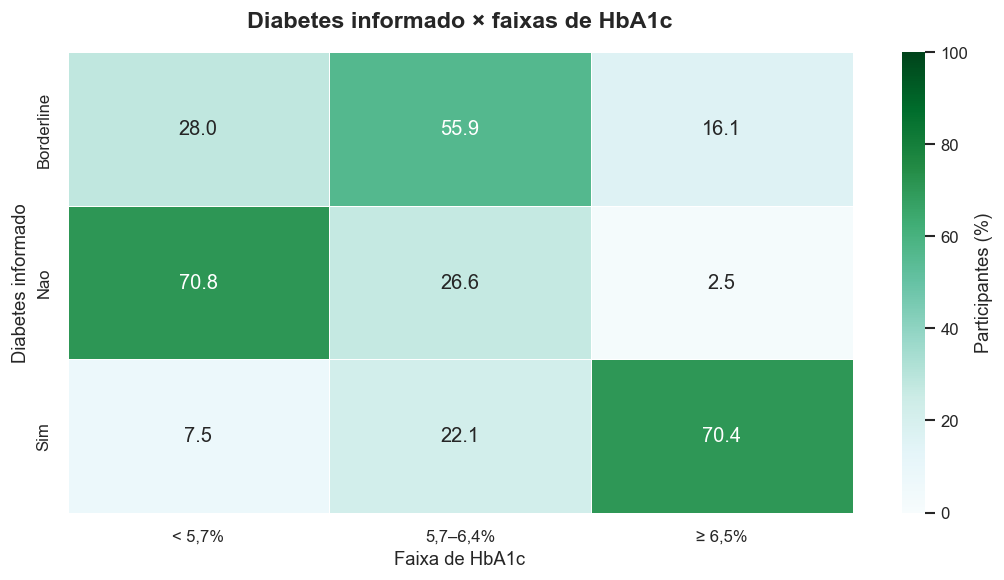

In [29]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    tabela_diabetes_hba1c_pct,
    annot=True,
    fmt=".1f",
    cmap="BuGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={
        "label": "Participantes (%)"
    }
)

plt.title(
    "Diabetes informado × faixas de HbA1c",
    pad=15,
    weight="bold"
)

plt.xlabel("Faixa de HbA1c")
plt.ylabel("Diabetes informado")

plt.tight_layout()
plt.show()

Entre os participantes que **não informaram diabetes**, 70,8% apresentaram HbA1c abaixo de 5,7%, 26,6% ficaram entre 5,7% e 6,4% e 2,5% apresentaram valores iguais ou superiores a 6,5%.

No grupo classificado como **Borderline**, a maior proporção, 55,9%, concentrou-se entre 5,7% e 6,4%, enquanto 16,1% apresentaram HbA1c igual ou superior a 6,5%.

Entre os participantes que **informaram diabetes**, 70,4% apresentaram HbA1c igual ou superior a 6,5%, enquanto 22,1% ficaram entre 5,7% e 6,4% e 7,5% apresentaram valores abaixo de 5,7%.

O heatmap evidencia uma associação entre o histórico informado de diabetes e as faixas de HbA1c, mas também mostra combinações distintas entre as duas informações.

Essas combinações não permitem identificar individualmente participantes como casos não diagnosticados, diagnósticos incorretos ou ausência da condição, pois a análise não dispõe do histórico clínico completo necessário para essas conclusões.

### 10.2 Hipertensão informada × pressão medida

**Pergunta da análise:** como a pressão arterial medida no exame se distribui segundo o histórico informado de hipertensão?

Para realizar a comparação, é construído um **critério analítico observado no exame**, considerando pressão sistólica igual ou superior a 130 mmHg ou pressão diastólica igual ou superior a 80 mmHg.

Esse indicador é utilizado apenas para organizar a análise descritiva. Ele não representa, isoladamente, um diagnóstico de hipertensão e não substitui avaliação clínica ou histórico de medições do participante.

Os percentuais são calculados dentro de cada categoria de hipertensão informada.

In [30]:
df["criterio_pressao_exame"] = np.where(
    (
        (df["pressao_sistolica"] >= 130)
        |
        (df["pressao_diastolica"] >= 80)
    ),
    "Sim",
    "Não"
)

df["hipertensao_label"] = (
    df["hipertensao_informada"]
    .map({
        0.0: "Não",
        1.0: "Sim"
    })
)

tabela_hipertensao_pressao = pd.crosstab(
    df["hipertensao_label"],
    df["criterio_pressao_exame"]
)

display(tabela_hipertensao_pressao)

criterio_pressao_exame,Não,Sim
hipertensao_label,,
Não,2269,1035
Sim,835,1141


In [31]:
tabela_hipertensao_pressao_pct = (
    pd.crosstab(
        df["hipertensao_label"],
        df["criterio_pressao_exame"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

display(tabela_hipertensao_pressao_pct)

criterio_pressao_exame,Não,Sim
hipertensao_label,,
Não,68.7,31.3
Sim,42.3,57.7


Entre os participantes que **não informaram hipertensão**, 68,7% ficaram abaixo do critério analítico utilizado, enquanto 31,3% atenderam ao critério no momento do exame.

Entre aqueles que **informaram hipertensão**, 42,3% ficaram abaixo do critério e 57,7% atenderam ao critério analítico observado.

Os resultados mostram diferenças entre os grupos, mas também evidenciam que histórico informado e pressão medida no exame não são informações equivalentes.

A presença ou ausência do critério analítico em uma única avaliação não permite confirmar ou descartar individualmente hipertensão.

In [32]:
pressao_plot = (
    tabela_hipertensao_pressao_pct
    .reindex(["Não", "Sim"])
    [["Não", "Sim"]]
)

display(pressao_plot)

criterio_pressao_exame,Não,Sim
hipertensao_label,,
Não,68.7,31.3
Sim,42.3,57.7


Para facilitar a comparação das proporções, os resultados são apresentados também em um gráfico de barras horizontais empilhadas. Cada barra representa 100% dos participantes de uma categoria de hipertensão informada.

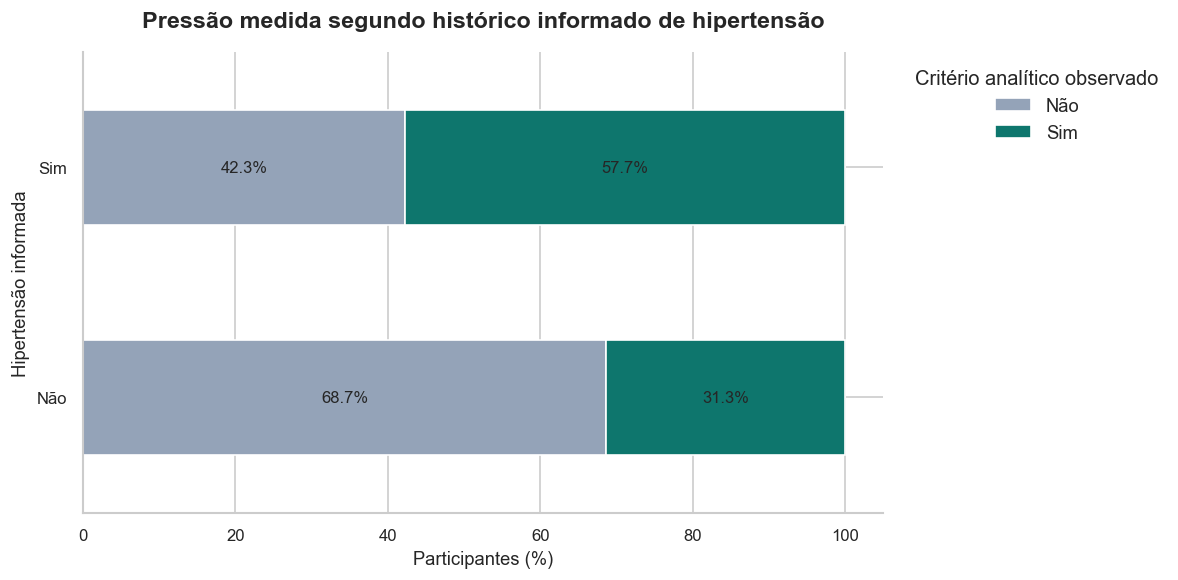

In [33]:
ax = pressao_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5),
    color=[
        COR_NEUTRA,
        COR_PRINCIPAL
    ]
)

plt.title(
    "Pressão medida segundo histórico informado de hipertensão",
    pad=15,
    weight="bold"
)

plt.xlabel("Participantes (%)")
plt.ylabel("Hipertensão informada")

plt.legend(
    title="Critério analítico observado",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    labels = [
        f"{valor:.1f}%"
        if valor >= 5
        else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10
    )

sns.despine()

plt.tight_layout()
plt.show()

### 10.3 Colesterol alto informado × colesterol medido

**Pergunta da análise:** como a medida atual de colesterol total se relaciona com o histórico informado de colesterol elevado?

Para facilitar a comparação, é utilizado um critério analítico de colesterol total igual ou superior a **200 mg/dL**.

Assim como nas comparações anteriores, esse ponto de corte é utilizado para organizar descritivamente os participantes e não para estabelecer individualmente um diagnóstico.

Os percentuais são calculados dentro de cada categoria de histórico informado de colesterol alto.

In [34]:
df["criterio_pressao_exame"] = np.where(
    df["colesterol_total"] >= 200,
    "Sim",
    "Não"
)

df["colesterol_alto_label"] = (
    df["colesterol_alto_informado"]
    .map({
        0.0: "Não",
        1.0: "Sim"
    })
)

tabela_colesterol = pd.crosstab(
    df["colesterol_alto_label"],
    df["criterio_pressao_exame"]
)

display(tabela_colesterol)

criterio_pressao_exame,Não,Sim
colesterol_alto_label,,
Não,1998,1050
Sim,1330,874


In [35]:
tabela_colesterol_pct = (
    pd.crosstab(
        df["colesterol_alto_label"],
        df["criterio_pressao_exame"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

display(tabela_colesterol_pct)

criterio_pressao_exame,Não,Sim
colesterol_alto_label,,
Não,65.6,34.4
Sim,60.3,39.7


Entre os participantes que **não informaram colesterol alto**, 65,6% apresentaram colesterol total abaixo de 200 mg/dL e 34,4% apresentaram valor igual ou superior a esse limite.

Entre aqueles que **informaram histórico de colesterol alto**, 60,3% apresentaram colesterol total abaixo de 200 mg/dL e 39,7% apresentaram valor igual ou superior.

As proporções são relativamente próximas entre os dois grupos, resultado consistente com a considerável sobreposição das distribuições observada anteriormente no perfil lipídico.

Assim como nas demais comparações desta seção, a diferença entre histórico informado e medida atual não deve ser interpretada automaticamente como inconsistência ou erro. As informações representam aspectos diferentes do histórico de saúde dos participantes.

### 10.4 Interpretação conjunta das comparações

As três análises mostram que informações de histórico e medidas objetivas apresentam relações diferentes na amostra.

No caso do diabetes, observa-se uma associação mais evidente entre o histórico informado e as faixas de HbA1c. Para hipertensão, também são observadas diferenças entre os grupos, embora exista uma proporção considerável de participantes em combinações distintas entre histórico e medida atual. No colesterol, as proporções entre os grupos apresentam diferenças menores.

Esses resultados reforçam que histórico informado e medida objetiva não devem ser tratados automaticamente como variáveis equivalentes.

Além disso, o grau de correspondência observado não deve ser interpretado como medida de qualidade do diagnóstico ou do relato dos participantes, pois a análise não dispõe de todas as informações clínicas necessárias para esse tipo de conclusão.

In [36]:
resumo_comparacoes = pd.DataFrame({
    "Comparação": [
        "Diabetes informado × HbA1c",
        "Hipertensão informada × pressão",
        "Colesterol alto informado × colesterol"
    ],

   "Informação objetiva": [
        "Faixas analíticas de HbA1c",
        "Critério analítico da pressão medida",
        "Critério analítico do colesterol total"
    ],

    "Objetivo": [
        "Comparar histórico com perfil glicêmico atual",
        "Comparar histórico com pressão medida no exame",
        "Comparar histórico com colesterol medido"
    ]
})

display(resumo_comparacoes)

,Comparação,Informação objetiva,Objetivo
0,Diabetes informado × HbA1c,Faixas analíticas de HbA1c,Comparar histórico com perfil glicêmico atual
1,Hipertensão informada × pressão,Critério analítico da pressão medida,Comparar histórico com pressão medida no exame
2,Colesterol alto informado × colesterol,Critério analítico do colesterol total,Comparar histórico com colesterol medido


### 10.5 Síntese das comparações

A tabela a seguir resume as três comparações realizadas nesta seção e destaca a diferença entre a informação de histórico e a medida objetiva utilizada em cada análise.

### 10.6 Síntese da seção

A comparação entre histórico informado e medidas objetivas mostrou que essas informações apresentam associações, mas não são equivalentes.

A relação foi mais evidente entre diabetes informado e faixas de HbA1c, enquanto as comparações envolvendo pressão arterial e colesterol apresentaram diferentes níveis de sobreposição entre as categorias analisadas.

Esses resultados não permitem determinar individualmente a presença ou ausência de uma condição clínica. Seu principal papel nesta EDA é demonstrar que histórico de saúde e medidas atuais representam informações distintas que precisam ser consideradas separadamente.

Essa conclusão entre histórico de saúde e medidas atuais possui relação direta com a proposta do HealthSync. e na futura etapa de Machine Learning, principalmente na definição dos targets e na prevenção de vazamento de informação entre variáveis preditoras e variáveis-alvo.